## Module 4: Cancer Hallmark

## Team Members:
*Abhiram Ruthala, Delaney Broderick*

## Project Title:
*The Impact of Immune Response Invasion Genes in individuals with Glioblastoma Across Different Ages*


## Project Goal:
This project seeks to understand how the different genes associated with the immune response invasion cancer hallmark is expressed in individuals with glioblastoma in different age ranges. Using the cancer hallmark of immune invasion response and the associated genes, to see if there is a difference in gene expression in individuals with glioblastoma by age. This can be used to help predict gene expression in certain age groups of those with glioblastoma. 

## Disease Background:

* Cancer Hallmark focus: Immune response evasion
* Overview of hallmark: 
    * Immune Response Evasion: Cancer cells are able to evade immune cells, such as Killer T cells, as they traverse through the human body and continue to develop uncontrollably. Due to this evasion, it makes it harder for the immune system to attack the cancer cells, causing the cancer to prevail for longer with minimal damage. This is a programming of the cancer cell as per its sense of dividing as much as possible.
* Genes associated with hallmark: Immune evasion hallmark includes key oncogenes such as MYC, RAS, and STAT3, and tumor suppressors TP53 and PTEN, which are important for immune suppresion and to avoid detection by key immune cells. 

### Background on Glioblastoma
Glioblastoma is an aggressive type of brain cancer that begins with astrocytes (support nerve cells). Specifically, glial cells - cells in the central and peripheral nervous system - that endure a major mutation/change in the DNA, which then causes them to fail within their own division processes, leading to glioblastoma. Glioblastoma is the most common malignant form of glioma, representing a wide array of glial cell-formed brain cancer.

It's the most common malignant brain tumor in adults and makes up about half of all malignant brain tumors in adults.

Within this group, glioblastoma is classified as a grade 4 glioma (Mayo Clinic, 2024a), the most serious type of glioma. Grade 4 means the tumor grows and spreads quickly into nearby brain tissue, which makes it hard to remove completely.

Symptoms:
Symptoms vary based on where the tumor forms in the brain and may involve seizures, brain swelling, headaches, personality changes, and changes in speech, vision, strength, sensation or balance.

There is no cure for glioblastoma. Treatments such as surgery, radiation and chemotherapy may slow tumor growth, ease symptoms and help people live longer. These are treatment methods that hope to put the cancer in remission by removing the mass, killing off cells that divide fast, and creating environments to where it is harder for such fast-dividing cells to live.

The cause of most glioblastomas is not known. A lot can be pointed to major mutations or transcription factor changes within glial cells that cause them to mishap when dividing as a means to support the brain's nutrition. Poor lifestyle choices compounded over years creates more effective breeding grounds for cancer as mistakes for cells are more prone, the body's immune response drops with time, and cells have accumulated damage from years of previous mistakes as well. 

Risk Factors: 
* Radiation exposure 
* Old age
* Being male
* Inherited syndromes like Lynch Syndrome and Li-Fraumeni syndrome

There are no known mechanisms as to prevent glioblastoma. A lot of general mechanisms point to public health awareness and lifestyle changes as being a deep factor, since that reduces the abilities for cells to drift, make changes, and have unnecessary mutations that would've taken place if not for proper cell management. However, people can still develop severe versions even when organized healthily, because biology's laws aren't limited.

### Citations

Mayo Clinic. (2024a). Astrocytoma - Symptoms and causes. Mayo Clinic. https://www.mayoclinic.org/diseases-conditions/astrocytoma/symptoms-causes/syc-20576675

Mayo Clinic. (2024b, June 20). Glioblastoma - Symptoms and causes. Mayo Clinic. https://www.mayoclinic.org/diseases-conditions/glioblastoma/symptoms-causes/syc-20569077


## Data-Set: 

We will be analyzing the metadata dataset first as a means to filter through and identify key factor points for Glioblastoma. After recognizing such pointers, we'll take a look into the training data, and filter within that for glioblastoma patients. Since we'd get a range of glioblastoma patients, we'd want to sort this data through age, and then format to find immune evasion factors, ideally through specific metabolic changes or gene expression changes.

The Cancer Genome Atlas RNA-seq dataset, re-processed by Rahman et al. The data set contains 24 cancer types. It contains 50-100 tumors per cancer type and the metadata includes ~20 columns from original 526. The rows of the metadata document that contains individuals with glioblastoma (GBM) were used in our analysis. 


### Citations

smgroves. (2025a). Module-4-Cancer/data/GSE62944_metadata_percent_nonNA_by_cancer_type.csv at main · smgroves/Module-4-Cancer. GitHub. https://github.com/smgroves/Module-4-Cancer/blob/main/data/GSE62944_metadata_percent_nonNA_by_cancer_type.csv

smgroves. (2025b). Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv at main · smgroves/Module-4-Cancer. GitHub. https://github.com/smgroves/Module-4-Cancer/blob/main/data/TRAINING_SET_GSE62944_metadata.csv






## Data Analysis: 

### Methods
The machine learning technique we are using is: Unsupervised learning
   Dimensionality reduction: 
        PCA- Find the “directions” in the dataset that give the most information (have the most variance). Done by “decomposing” the matrix of data features into new features (PC1, PC2, etc)
Supervised learning:
   Clustering:
    K-Means clustering- Used to find groups of commonality in the data
    Hierarchical Clustering- group most similar samples and then groups of groups
    
    

*What is this method optimizing? How does the model decide it is "good enough"?*

**
validation data set for out of sample error and training set for in sample error

### Analysis



**The In-Class Clustering notebook was used heavily to guide the following code**

*Import needed libraries for organizing and subsetting data*

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error

*Load in the data sets*

In [88]:
data = pd.read_csv(
    r"C:\Users\dance\OneDrive - University of Virginia\Computational BME\Module-4-Cancer\data\TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0, header=0)  # can also use larger dataset with more genes
metadata_df = pd.read_csv(
    r"C:\Users\dance\OneDrive - University of Virginia\Computational BME\Module-4-Cancer\data\TRAINING_SET_GSE62944_metadata.csv", index_col=0, header=0)


*Get data about chosen cancer type: Glioblastoma (GBM), and genes linked to immune invasion from the Menyhart document*

In [89]:
cancer_type = 'GBM' 
GBM_metadata = metadata_df[metadata_df['cancer_type'] == cancer_type]
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
GBM_data = data[cancer_samples]
desired_gene_list = ['STAT1', 'CXCR4', 'PTPN6', 'RHOA', 'STAT3', 'LCK', 'CD86', 'MAPK14', 'HCK', 'PTK2', 'HIF1A', 'PRF1', 'IL12A', 'CXCL12', 'ARRB1', 'GNAI2', 'PLCG1', 'PTPN11', 'CARD11', 'PIK3CD', 'PTK2B', 'BCL6', 'MAP2K2', 'NRAS', 'CD40LG', 'IL4', 'RAF1', 'CCL2', 'FYN', 'VAV2', 'CIITA', 'ARRB2', 'JAK3', 'IFNGR1', 'KRAS', 'IL6', 'SH2D1B', 'IL1B', 'CD3D', 'CD3E', 'CD40', 'MAPK1', 'LYN', 'PIK3R1', 'SOS1', 'GNB1', 'ADRBK1', 'FCGR3B', 'PTPRC', 'HCST', 'JAK2', 'CD28', 'PDCD1', 'FCGR3A', 'AKT1', 'CD8B', 'IRF7', 'PIK3CG', 'GNG2', 'AKT2', 'SHC1', 'HLA-A', 'IL2', 'AKT3', 'MAPK3', 'SH2D1A', 'FGR', 'B2M', 'PRKCD', 'SRC', 'PLCB3', 'CXCL10', 'MAP2K1', 'CD3G', 'ZAP70', 'IFNG', 'IKBKB', 'ITGB2', 'IL8', 'IL2RG', 'CBL', 'IL12B', 'PLCB2', 'CTNNB1', 'CD247', 'PIK3R3', 'TRAF6', 'CCL26', 'FES', 'CXCR1', 'PIK3R2', 'PIK3CB', 'CXCL9', 'VAV3', 'ITGAM', 'CD80', 'MAPK11', 'IL7R', 'PRKCB', 'HRAS', 'CBLB', 'RAC1', 'JAK1', 'TIAM1', 'GRB2', 'PIK3CA']
gene_list = [gene for gene in desired_gene_list if gene in GBM_data.index]


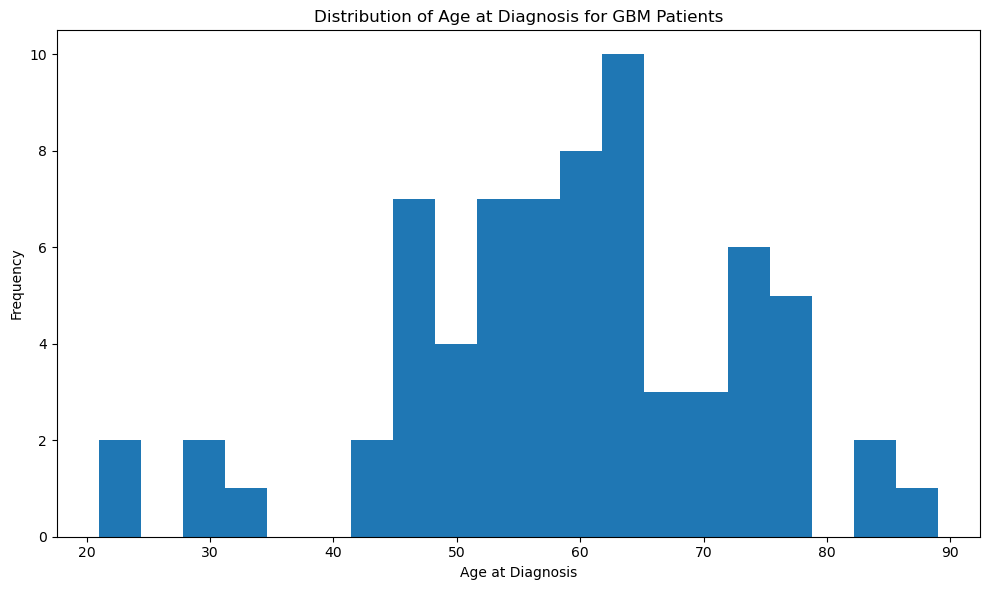

In [90]:
cleaned = GBM_metadata.copy()
cleaned['age_at_diagnosis'] = pd.to_numeric(cleaned['age_at_diagnosis'], errors='coerce')

plt.figure(figsize=(10, 6))
plt.hist(cleaned['age_at_diagnosis'].dropna(), bins=20)
plt.xlabel('Age at Diagnosis')
plt.ylabel('Frequency')
plt.title('Distribution of Age at Diagnosis for GBM Patients')
plt.tight_layout()
plt.show()


In [91]:
scaler = StandardScaler()
X = GBM_data.loc[gene_list].values.T
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
y_age = GBM_metadata['age_at_diagnosis']
valid_indices = y_age.dropna().index
y_age = y_age.loc[valid_indices]
valid_indices = y_age.dropna().index
y_age = y_age.loc[valid_indices]

*Create bins for the different age groups and then plot the PCA using the age groups*

C:\Users\dance\AppData\Local\Temp\ipykernel_23824\1284079006.py:9: SettingWithCopyWarning: 
,A value is trying to be set on a copy of a slice from a DataFrame.
,Try using .loc[row_indexer,col_indexer] = value instead
,
,See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
,  GBM_metadata['age_group'] = cleaned.loc[GBM_metadata.index, 'age_group']


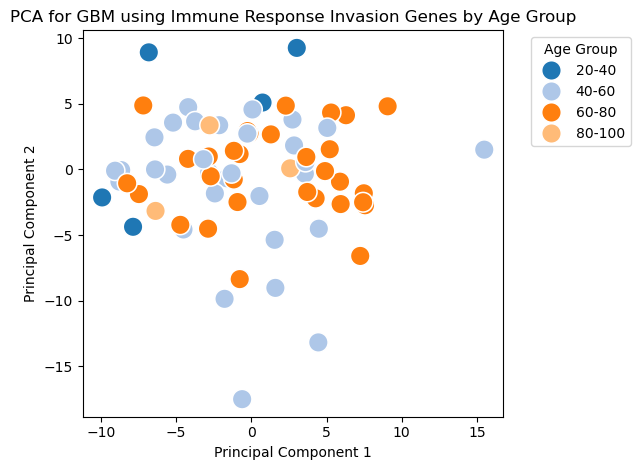

In [92]:
# Create age bins and groups
age_bins = [20, 40, 60, 80, 100]
age_labels = ['20-40', '40-60', '60-80', '80-100']
cleaned = GBM_metadata.copy()
cleaned['age_at_diagnosis'] = pd.to_numeric(cleaned['age_at_diagnosis'], errors='coerce')
cleaned['age_group'] = pd.cut(cleaned['age_at_diagnosis'], bins=age_bins, labels=age_labels, right=False)

# Update GBM_metadata with age groups
GBM_metadata['age_group'] = cleaned.loc[GBM_metadata.index, 'age_group']

# Plot the PCA with age groups as hue
sns.scatterplot(x=X_pca[:, 0], 
                y=X_pca[:, 1], 
                hue=GBM_metadata['age_group'].values,
                palette="tab20", 
                s=200)

plt.title("PCA for GBM using Immune Response Invasion Genes by Age Group")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Age Group")
plt.tight_layout()
plt.show()

*K Means Clustering*

c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
,  warnings.warn(
,C:\Users\dance\AppData\Local\Temp\ipykernel_23824\2014395780.py:11: SettingWithCopyWarning: 
,A value is trying to be set on a copy of a slice from a DataFrame.
,Try using .loc[row_indexer,col_indexer] = value instead
,
,See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
,  GBM_metadata.loc[X_with_age.index, 'cluster'] = cluster_labels


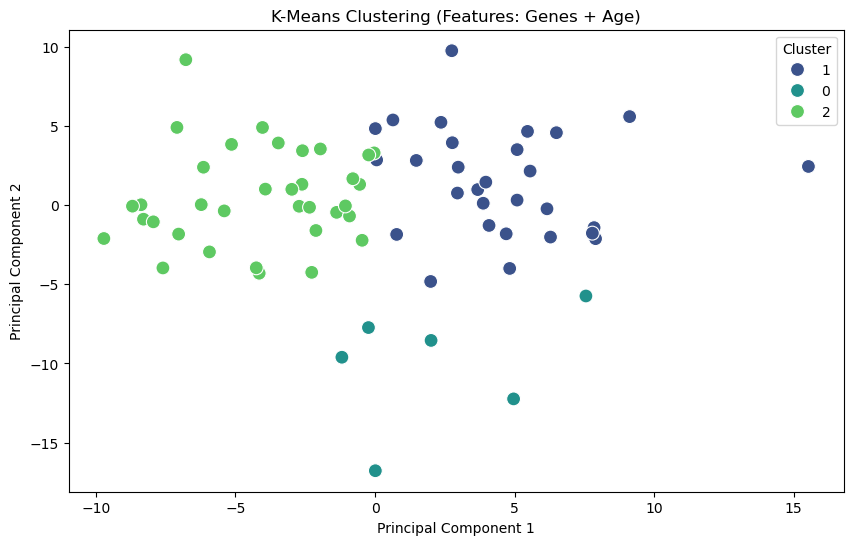

In [93]:
X_genes = GBM_data.loc[gene_list].T
X_with_age = X_genes.copy()
X_with_age['age'] = GBM_metadata.loc[X_with_age.index, 'age_at_diagnosis']
X_with_age = X_with_age.dropna()
filtered_metadata = GBM_metadata.loc[X_with_age.index]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_with_age)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled).astype(str)
GBM_metadata.loc[X_with_age.index, 'cluster'] = cluster_labels

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=cluster_labels, # This ensures the legend has "artists" to find
    palette='viridis', 
    s=100,
    legend='full'       # Explicitly tells seaborn to build the legend
)
plt.title(f"K-Means Clustering (Features: Genes + Age)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

*Hierarchical Clustering using in-class notebook for a guide*

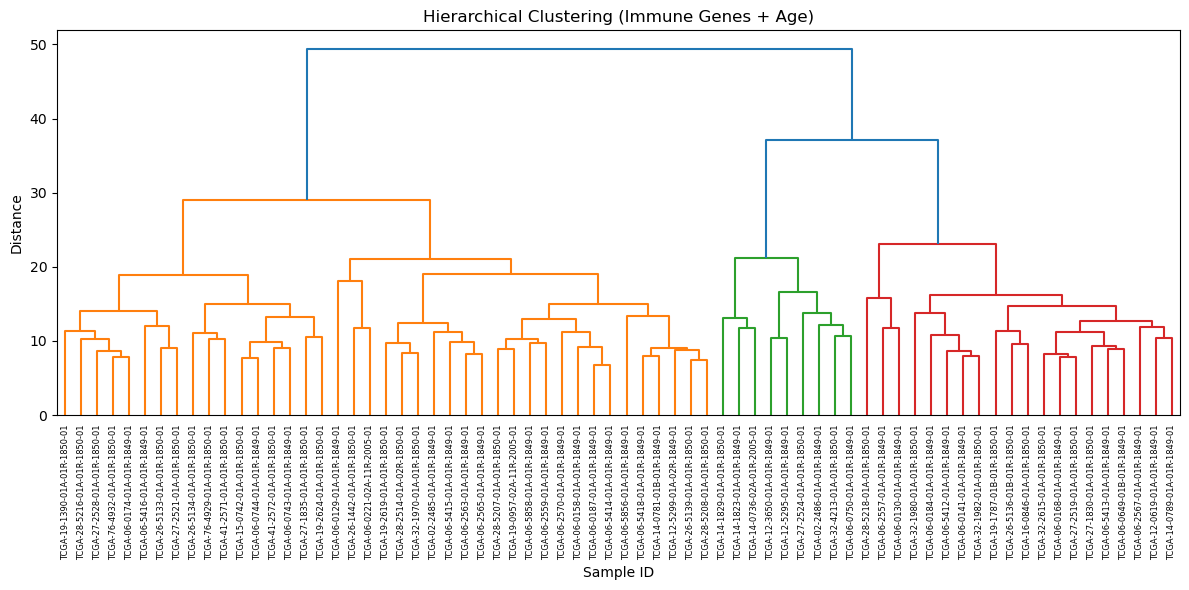

In [94]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=X_with_age.index.values)
plt.title("Hierarchical Clustering (Immune Genes + Age)")
plt.xlabel("Sample ID")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Machine Learning Model

We built a linear regression model to help predict gene expression of immune evasion genes based on age. We trained the model on specific data acquired from the TRAINING_DATA_SUBSAMPLE and TRAINING_DATA_METADATA, and created a working system that attempts to figure out the gene expression of specific immune evasion genes when inputting an age. Here's the build:

In [ ]:
# Credit: Claude as AI assistance to help build the code

# Import the necessary files
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Load all the data
# CSV structure: rows = genes, columns = patients (each cell = log2TPM expression value)
df = pd.read_csv('/Users/abhiramruthala/Module-4-Cancer/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0)

# all the immune evasion genes that we're exploring
desired_genes = ['STAT1', 'CXCR4', 'PTPN6', 'RHOA', 'STAT3',
                 'LCK', 'CD86', 'MAPK14', 'HCK', 'PTK2', 'HIF1A', 'PRF1']

# Pull just the 12 genes we care about → shape: (12 genes, 1802 patients)
gene_df = df.loc[desired_genes]

# Patient age metadata (from the GBM clinical file)
# Key = TCGA patient ID, Value = age at diagnosis
patient_ages = {
    'TCGA-06-0184': 63, 'TCGA-27-2524': 56, 'TCGA-27-1835': 53,
    'TCGA-26-5139': 65, 'TCGA-06-2567': 65, 'TCGA-28-5216': 52,
    'TCGA-06-0168': 59, 'TCGA-32-1980': 72, 'TCGA-76-4932': 50,
    'TCGA-06-2557': 76, 'TCGA-06-0141': 62, 'TCGA-26-5136': 78,
    'TCGA-14-1823': 58, 'TCGA-15-0742': 65, 'TCGA-41-2572': 67,
    'TCGA-26-5133': 59, 'TCGA-06-2570': 21, 'TCGA-19-1390': 63,
    'TCGA-28-5208': 52, 'TCGA-12-3650': 46, 'TCGA-16-0846': 85,
    'TCGA-12-5299': 56, 'TCGA-32-1982': 76, 'TCGA-06-0174': 54,
    'TCGA-19-2619': 55, 'TCGA-19-2624': 51, 'TCGA-06-5413': 67,
    'TCGA-27-1830': 57, 'TCGA-12-5295': 60, 'TCGA-27-2528': 62,
    'TCGA-26-5134': 74, 'TCGA-06-0158': 73, 'TCGA-06-0187': 69,
    'TCGA-06-0649': 73, 'TCGA-28-5207': 71, 'TCGA-06-5414': 61,
    'TCGA-06-5412': 78, 'TCGA-26-1442': 43, 'TCGA-06-0744': 66,
    'TCGA-12-0619': 60, 'TCGA-28-2514': 45, 'TCGA-06-5418': 75,
    'TCGA-06-5858': 45, 'TCGA-76-4929': 76, 'TCGA-06-5415': 60,
    'TCGA-06-0743': 69, 'TCGA-06-2563': 72, 'TCGA-06-5416': 23,
    'TCGA-14-0789': 54, 'TCGA-02-2485': 53, 'TCGA-32-1970': 59,
    'TCGA-06-0129': 30, 'TCGA-06-2565': 59, 'TCGA-41-2571': 89,
    'TCGA-06-0221': 31, 'TCGA-14-0736': 49, 'TCGA-32-4213': 47,
    'TCGA-02-2486': 64, 'TCGA-06-0750': 43, 'TCGA-06-2559': 83,
    'TCGA-19-0957': 48, 'TCGA-06-0130': 54, 'TCGA-27-2519': 48,
    'TCGA-19-1787': 48, 'TCGA-27-2521': 34, 'TCGA-14-0781': 49,
    'TCGA-14-1829': 57, 'TCGA-06-5856': 58, 'TCGA-32-2615': 62,
}

# Match patients with the specific gene expressions, so take the TCGA code and connect it with the specific gene expressions as listed in the data set.

ages = []
gene_matrix = []  # will be in the shape: (n_matched_patients, 12)

for col in gene_df.columns:
    patient_id = '-'.join(col.split('-')[:3])  
    if patient_id in patient_ages:
        ages.append(patient_ages[patient_id])
        gene_matrix.append(gene_df[col].values)  # all 12 gene values for this patient and every other.

ages = np.array(ages, dtype=np.float32)               # shape: (n_patients,)
gene_matrix = np.array(gene_matrix, dtype=np.float32) # shape: (n_patients, 12)

print(f"Matched {len(ages)} patients with both age and expression data")
print(f"Age range: {ages.min():.0f} – {ages.max():.0f}")
print(f"Gene matrix shape: {gene_matrix.shape}  (patients × genes)")

# We now plan to train one model per gene, since it brings specificity and allows for understanding of the role each gene plays as the age progresses.
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(1, input_shape=(1,))  # single linear layer = linear regression
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Create list of models and add the specific models to the specific genes in the list.
models = {}
for i, gene in enumerate(desired_genes):
    y = gene_matrix[:, i]  # expression values for this one gene across all patients
    m = create_model()
    m.fit(ages, y, epochs=1000, verbose=0)
    models[gene] = m
    print(f"Trained model for {gene}")

# Predict for a given age by giving the user the ability to do so.
input_age = float(input("\nWhat age would you like to predict for? "))
input_tensor = tf.convert_to_tensor([[input_age]], dtype=tf.float32)

# Use the predicted value for the specific gene and see what the gene expression would be at the specific age.
print(f"\nPredicted log2TPM expression at age {input_age:.0f}:")
predictions = {}
for gene, model in models.items():
    pred = model.predict(input_tensor, verbose=0)[0][0]
    predictions[gene] = pred
    print(f"  {gene:10s}: {pred:.4f}")

# Plot one scatter and regression line per gene. This helps conduct a machine learning understanding for all of the genes for a more comprehensive understanding of immune response.
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

# range of ages to which we are testing for.
age_range = np.linspace(ages.min() - 5, ages.max() + 5, 100).reshape(-1, 1).astype(np.float32)

# Create specific plots for specific genes as to not mix anything up and make things work correctly.
for i, gene in enumerate(desired_genes):
    ax = axes[i]
    y = gene_matrix[:, i]
    
    # Scatter: actual patient data
    ax.scatter(ages, y, color='steelblue', alpha=0.7, s=40, label='Patients')
    
    # Line: model's learned regression
    preds_line = models[gene].predict(age_range, verbose=0).flatten()
    ax.plot(age_range, preds_line, color='red', linewidth=2, label='Regression')
    
    # Mark the prediction for the input age so that the graphs are corresponding correctly.
    ax.axvline(input_age, color='orange', linestyle='--', alpha=0.7)
    ax.scatter([input_age], [predictions[gene]], color='orange', s=80, zorder=5, label=f'Age {input_age:.0f}')
    
    ax.set_title(gene, fontweight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('log2TPM')
    if i == 0:
        ax.legend(fontsize=7)

# Format everything and plot the data altogether.
plt.suptitle('Immune Evasion Gene Expression vs. Age (Linear Regression)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gene_expression_predictions.png', dpi=150)
plt.show()
print("\nPlot saved as gene_expression_predictions.png")

Necessary notes to make: The validation data did not have any GBM data, so we could not make use of validation data within the system. Additionally, for overfitting/underfitting determination, the usual procedure is to do a train/test split to see how it compares, but since we weren't allowed to use testing data, we ended up using a residual plot system to see how predicted values compare to actual values, and we see if the predicted is over or under over a range of values, which then would tell us if it is overfitted or underfitted.

The model did come out to be underfitted by the data due to the predicted values coming out to be on the lower end than what the actual values were, because age isn't the best predictor of gene expression and that there are so many more factors that play into gene expression, so its hard to get a proper value when just using age-based metrics to do so.

For the means of seeing how well the model performed, we used an R^2 for the regression to understand the variance between the data, which in this case is age vs. gene expression. Since age isn't the best predictor of gene expression, and since there are many more variables other than age that checks for gene expression, we expect the values to be low. 

In [ ]:
# Code for the R^2 calculation.
from sklearn.metrics import r2_score
 
print("\nModel Evaluation (Training Data):")
print(f"{'Gene':<12} {'R²':>8} {'Interpretation'}")
print("-" * 45)

# get R^2 for all designated genes as to see variance. the code outputs a table to see the variance across all genes.
r2_scores = {}
for i, gene in enumerate(desired_genes):
    y_actual = gene_matrix[:, i]
    y_predicted = models[gene].predict(ages.reshape(-1, 1), verbose=0).flatten()
    
    r2 = r2_score(y_actual, y_predicted)
    r2_scores[gene] = r2
    
    # Simple interpretation using if-else statements to determine how the model is doing in terms of the dataset.
    if r2 >= 0.7:
        interp = "Good fit"
    elif r2 >= 0.3:
        interp = "Moderate fit"
    elif r2 >= 0:
        interp = "Weak fit (likely underfit)"
    else:
        interp = "Worse than mean baseline"
    
    print(f"{gene:<12} {r2:>8.4f}  {interp}")

# Code for the residual plot
 
fig2, axes2 = plt.subplots(3, 4, figsize=(16, 10))
axes2 = axes2.flatten()
 
for i, gene in enumerate(desired_genes):
    ax = axes2[i]
    y_actual = gene_matrix[:, i]
    y_predicted = models[gene].predict(ages.reshape(-1, 1), verbose=0).flatten()
    residuals = y_actual - y_predicted
 
    ax.scatter(ages, residuals, color='steelblue', alpha=0.7, s=40)
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')  # zero line
    ax.set_title(f"{gene}  (R²={r2_scores[gene]:.3f})", fontweight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('Residual')

# Format the residual plot to see how predicted values compare to actual values to determine underfitting/overfitting.
plt.suptitle('Residual Plots — Check for Patterns (Pattern = Underfit, Random = Good)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150)
plt.show()
print("\nResidual plots saved as residual_plots.png")

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*